In [ ]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")

plt.rcParams.update({
    "text.usetex": False,           
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "DejaVu Serif"], 
    "font.size": 8,                
    "axes.titlesize": 9,            
    "axes.labelsize": 8,           
    "legend.fontsize": 7,           
    "legend.title_fontsize": 7,     
    "xtick.labelsize": 7,           
    "ytick.labelsize": 7,
    "figure.figsize": (4.8, 3.0),   
    "figure.dpi": 300
})

def load_jsonl(path, split_name):
    data = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            item = json.loads(line)
            text = item['text']
            
            language = "Spanish" if "Veredicto del Auditor" in text else "English"
            is_hallucination = "Sí" in text.split("\n")[-1] or "Yes" in text.split("\n")[-1]
            
            data.append({
                "split": split_name,
                "language": language,
                "hallucination": "Yes (Hallucination)" if is_hallucination else "No (Clean)",
                "character_length": len(text)
            })
    return pd.DataFrame(data)

df_train = load_jsonl("train_95en_5es.jsonl", "Train")
df_val = load_jsonl("val_95en_5es.jsonl", "Validation")
df_test = load_jsonl("evaluacion_1200_es.jsonl", "Test")

df_total = pd.concat([df_train, df_val, df_test], ignore_index=True)
print("Data loaded successfully!")

Data loaded successfully!


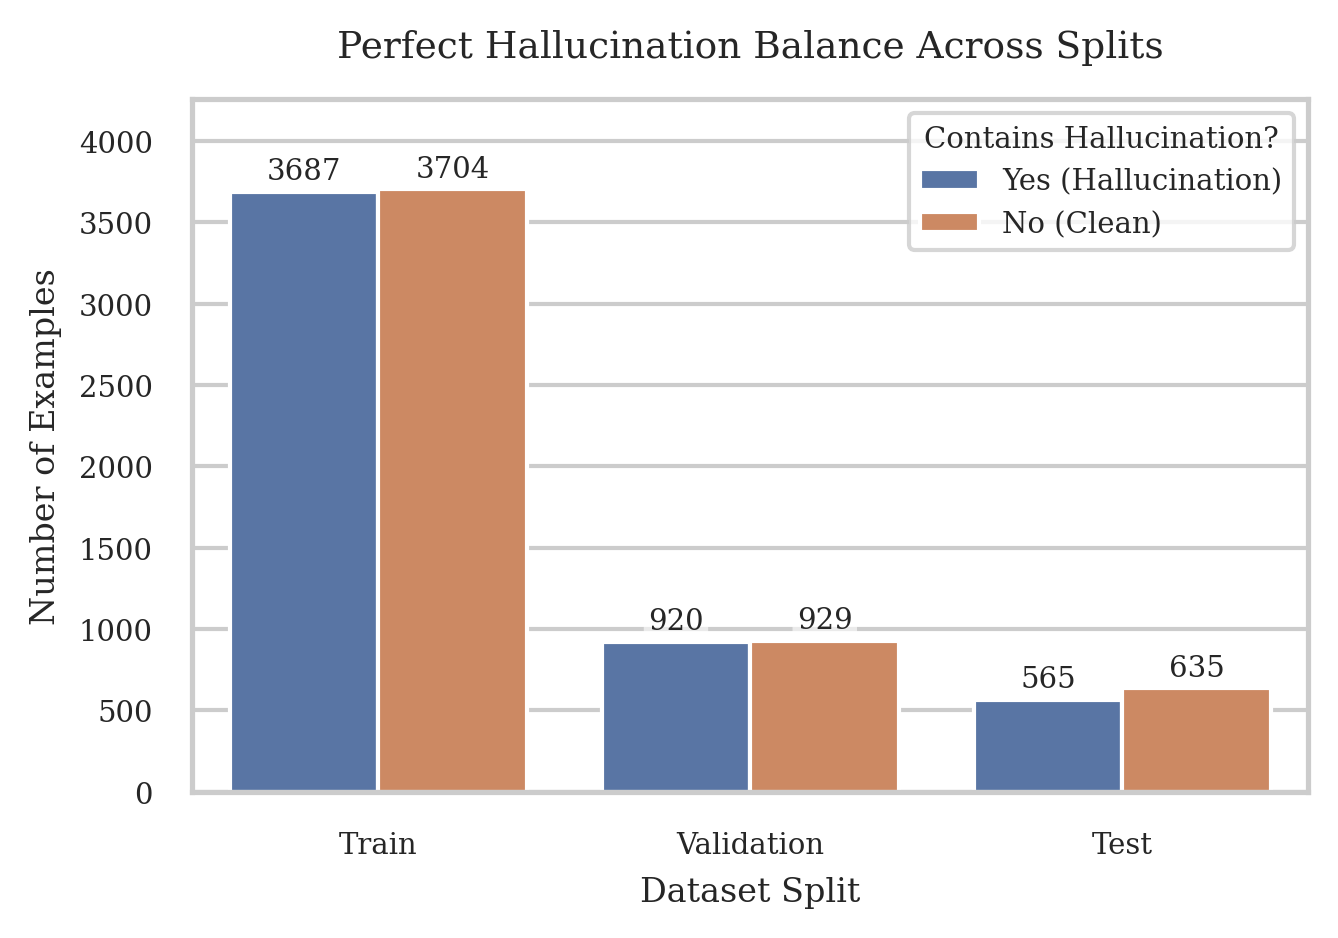

In [ ]:
fig, ax = plt.subplots()

sns.countplot(data=df_total, x='split', hue='hallucination', palette='deep', order=['Train', 'Validation', 'Test'], ax=ax)

ax.set_title('Perfect Hallucination Balance Across Splits', pad=10)
ax.set_ylabel('Number of Examples')
ax.set_xlabel('Dataset Split')
ax.legend(title='Contains Hallucination?')

max_height = max([p.get_height() for p in ax.patches if p.get_height() > 0])
ax.set_ylim(top=max_height * 1.15)  

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=7, 
                    xytext=(0, 3), textcoords='offset points',
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.6, ec="none"))

plt.savefig("fig_hallucination_balance.pdf", bbox_inches="tight")
plt.show()

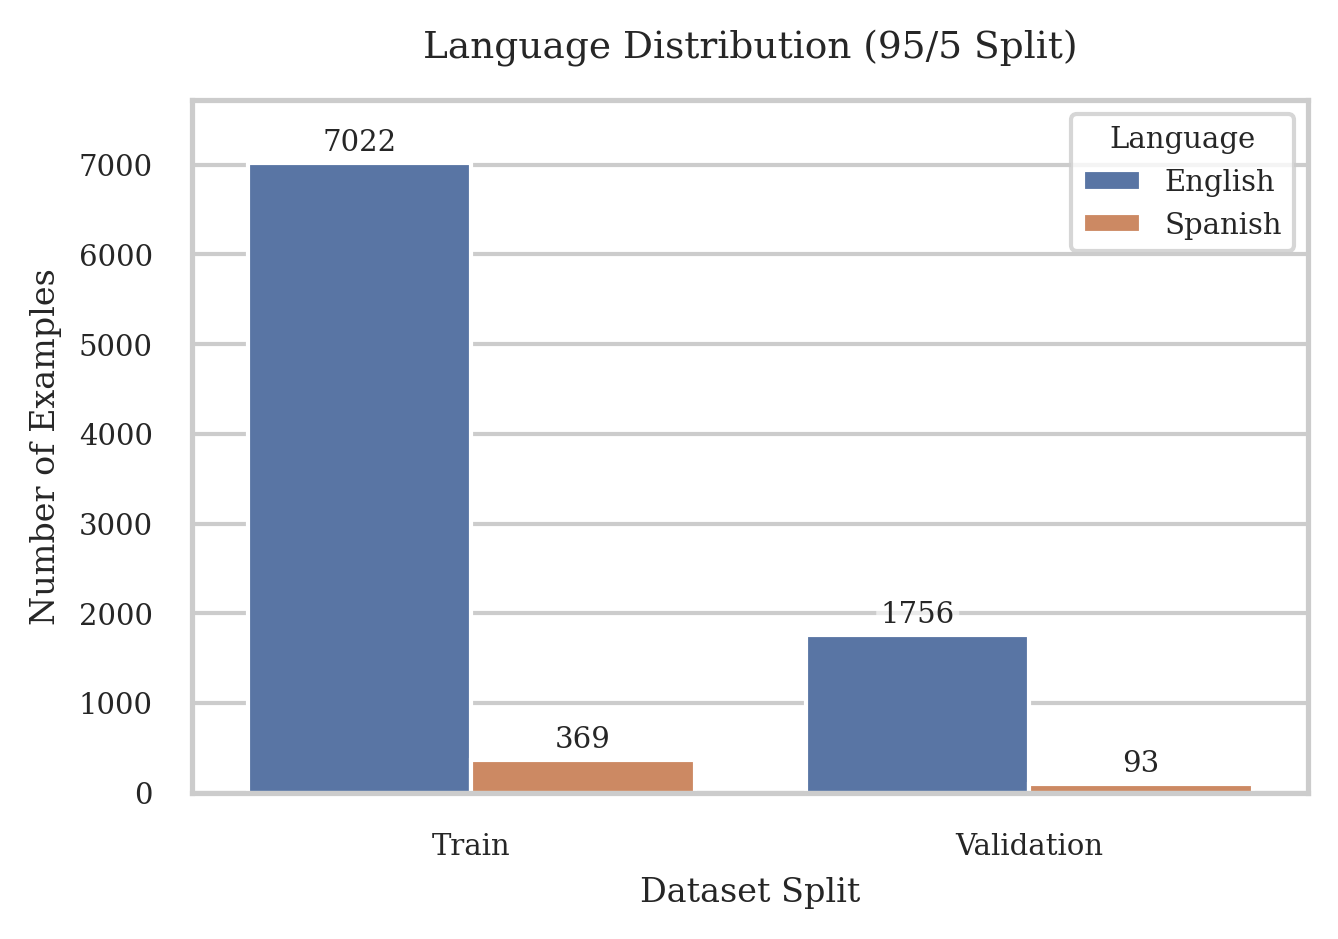

In [ ]:
df_train_val = df_total[df_total['split'].isin(['Train', 'Validation'])]

fig, ax = plt.subplots()

sns.countplot(data=df_train_val, x='split', hue='language', palette='deep', ax=ax)

ax.set_title('Language Distribution (95/5 Split)', pad=10)
ax.set_ylabel('Number of Examples')
ax.set_xlabel('Dataset Split')
ax.legend(title='Language')

max_height_val = max([p.get_height() for p in ax.patches if p.get_height() > 0])
ax.set_ylim(top=max_height_val * 1.10)  

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=7, 
                    xytext=(0, 3), textcoords='offset points',
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.6, ec="none"))

# Guardar vector
plt.savefig("fig_language_distribution.pdf", bbox_inches="tight")
plt.show()

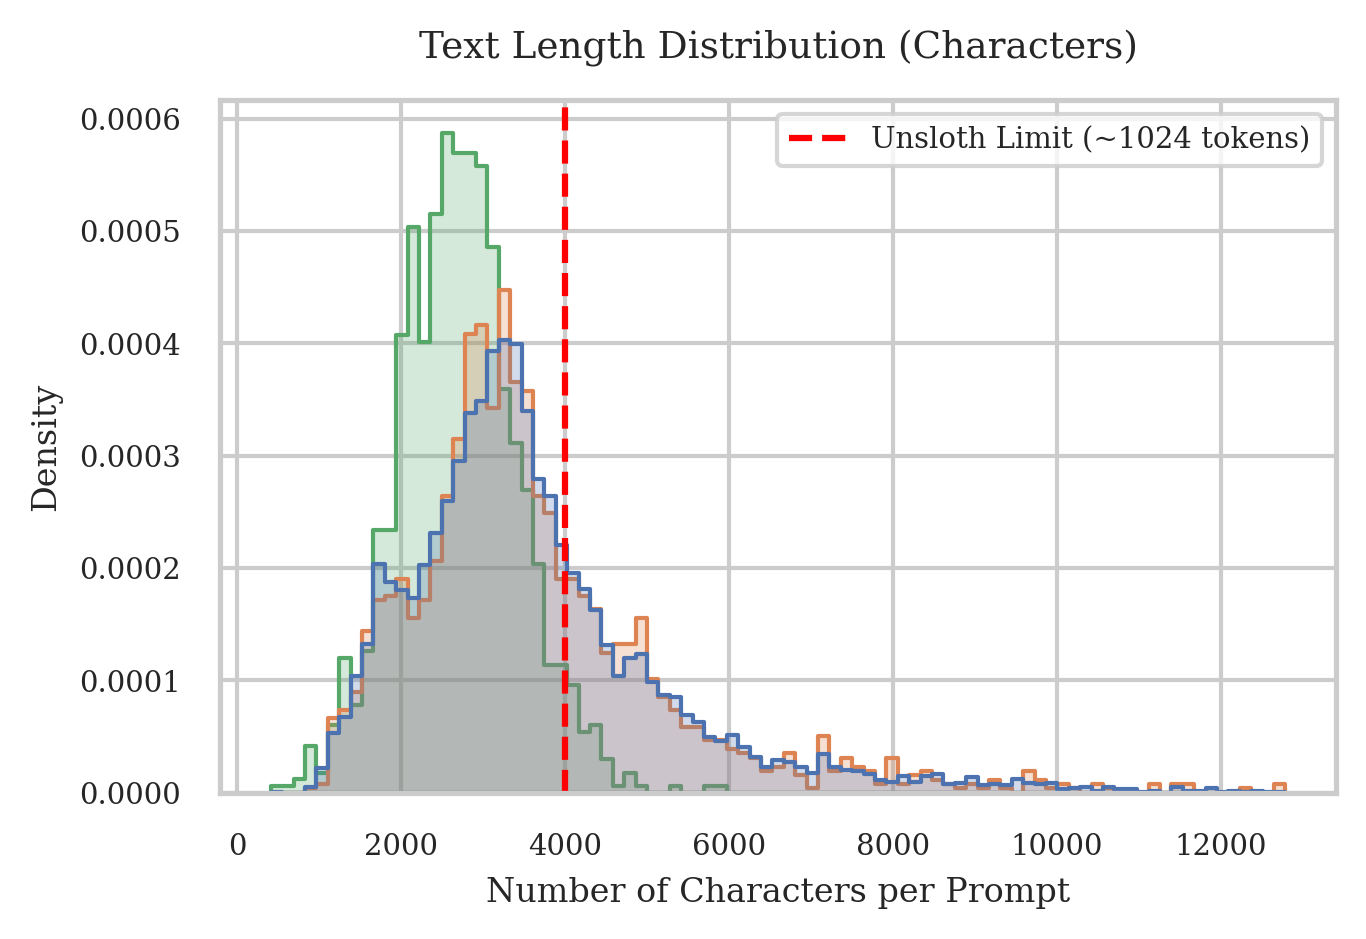

In [ ]:
fig, ax = plt.subplots()

sns.histplot(data=df_total, x='character_length', hue='split', palette='deep', element='step', stat='density', common_norm=False, ax=ax)

ax.set_title('Text Length Distribution (Characters)', pad=10)
ax.set_xlabel('Number of Characters per Prompt')
ax.set_ylabel('Density')

ax.axvline(x=4000, color='red', linestyle='--', label='Unsloth Limit (~1024 tokens)')
ax.legend()

plt.savefig("fig_text_length.pdf", bbox_inches="tight")
plt.show()